### Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import stats

# Exploration des données

## Chargement des fichiers

In [4]:
products = pd.read_csv(".\\Data\\products.csv", sep=";")
customers = pd.read_csv(".\\Data\\customers.csv", sep=";")
transactions = pd.read_csv(".\\Data\\Transactions.csv", sep=";", low_memory=False)

## Aperçu rapide de chaque table

### Products

In [5]:
print(f"Shape : {products.shape}")
print(f"\nColonnes : {list(products.columns)}")
print(f"\nTypes :\n{products.dtypes}")
print(f"\nValeurs manquantes :\n{products.isnull().sum()}")
print(f"\nAperçu :\n{products.head()}")
print(f"\nDescription :\n{products.describe(include='all')}")

Shape : (3286, 3)

Colonnes : ['id_prod', 'price', 'categ']

Types :
id_prod        str
price      float64
categ        int64
dtype: object

Valeurs manquantes :
id_prod    0
price      0
categ      0
dtype: int64

Aperçu :
  id_prod  price  categ
0  0_1421  19.99      0
1  0_1368   5.13      0
2   0_731  17.99      0
3   1_587   4.99      1
4  0_1507   3.99      0

Description :
       id_prod        price        categ
count     3286  3286.000000  3286.000000
unique    3286          NaN          NaN
top     0_1421          NaN          NaN
freq         1          NaN          NaN
mean       NaN    21.863597     0.370359
std        NaN    29.849786     0.615446
min        NaN     0.620000     0.000000
25%        NaN     6.990000     0.000000
50%        NaN    13.075000     0.000000
75%        NaN    22.990000     1.000000
max        NaN   300.000000     2.000000


Pour plus de finesse, affichage des potentiels doublons et lignes vides:

In [6]:
print(f"Products   : {products.duplicated().sum()} doublons")
all_null_products = products.isnull().all(axis=1).sum()
print(f"Products     : {all_null_products}")

Products   : 0 doublons
Products     : 0


In [7]:
print(f"\nValeurs uniques de categ : {sorted(products['categ'].unique())}")


Valeurs uniques de categ : [np.int64(0), np.int64(1), np.int64(2)]


Données "propres", 3286 lignes, prix entre 0.62 et 300, et 3 catégories (0, 1, 2) qui pourraient être stringifiées

### Customers

In [8]:
print(f"Shape : {customers.shape}")
print(f"\nColonnes : {list(customers.columns)}")
print(f"\nTypes :\n{customers.dtypes}")
print(f"\nValeurs manquantes :\n{customers.isnull().sum()}")
print(f"\nAperçu :\n{customers.head()}")
print(f"\nDescription :\n{customers.describe(include='all')}")

Shape : (8621, 3)

Colonnes : ['client_id', 'sex', 'birth']

Types :
client_id      str
sex            str
birth        int64
dtype: object

Valeurs manquantes :
client_id    0
sex          0
birth        0
dtype: int64

Aperçu :
  client_id sex  birth
0    c_4410   f   1967
1    c_7839   f   1975
2    c_1699   f   1984
3    c_5961   f   1962
4    c_5320   m   1943

Description :
       client_id   sex        birth
count       8621  8621  8621.000000
unique      8621     2          NaN
top       c_4410     f          NaN
freq           1  4490          NaN
mean         NaN   NaN  1978.275606
std          NaN   NaN    16.917958
min          NaN   NaN  1929.000000
25%          NaN   NaN  1966.000000
50%          NaN   NaN  1979.000000
75%          NaN   NaN  1992.000000
max          NaN   NaN  2004.000000


Pour plus de finesse, affichage des potentiels doublons et lignes vides:

In [9]:
print(f"Customers  : {customers.duplicated().sum()} doublons")
all_null_customers = customers.isnull().all(axis=1).sum()
print(f"Customers    : {all_null_customers}")

Customers  : 0 doublons
Customers    : 0


Données "propres", 8621 lignes, 2 sex (f, m) avec une répartition presque équilibrée (4490, 4131) et des années de naissance de 1929 à 2004

### Transactions

In [10]:
print(f"Shape : {transactions.shape}")
print(f"\nColonnes : {list(transactions.columns)}")
print(f"\nTypes :\n{transactions.dtypes}")
print(f"\nValeurs manquantes :\n{transactions.isnull().sum()}")
print(f"\nAperçu :\n{transactions.head()}")
print(f"\nDescription :\n{transactions.describe(include='all')}")

Shape : (1048575, 4)

Colonnes : ['id_prod', 'date', 'session_id', 'client_id']

Types :
id_prod       str
date          str
session_id    str
client_id     str
dtype: object

Valeurs manquantes :
id_prod       361041
date          361041
session_id    361041
client_id     361041
dtype: int64

Aperçu :
  id_prod                        date session_id client_id
0  0_1259  2021-03-01 00:01:07.843138        s_1     c_329
1  0_1390  2021-03-01 00:02:26.047414        s_2     c_664
2  0_1352  2021-03-01 00:02:38.311413        s_3     c_580
3  0_1458  2021-03-01 00:04:54.559692        s_4    c_7912
4  0_1358  2021-03-01 00:05:18.801198        s_5    c_2033

Description :
       id_prod                        date session_id client_id
count   687534                      687534     687534    687534
unique    3265                      687419     345505      8600
top      1_369  2021-10-02 01:17:27.925296   s_118668    c_1609
freq      2340                           2         14     25586


Pour plus de finesse, affichage des potentiels doublons et lignes vides:

In [11]:
print(f"Transactions : {transactions.duplicated().sum()} doublons")
all_null_transactions = transactions.isnull().all(axis=1).sum()
print(f"Transactions : {all_null_transactions}")

Transactions : 361040 doublons
Transactions : 361041


Données non "propres", 361041 lignes vides causent 361040 doublons, à revérifier après nettoyage.
3265 produits uniques, "date" en string, à convertir en "date" et 8600 clients uniques.
En comparant avec les tables products et customers, il y a 21 produits jamais vendus et 21 clients sans transaction

# Nettoyage

## Suppression des lignes vides

### Suppression

In [12]:
transactions = transactions.dropna(how="all")
all_null_transactions = transactions.isnull().all(axis=1).sum()
print(f"Transactions : {all_null_transactions}")

Transactions : 0


### Recherche de lignes partiellement vides

In [13]:
print(f"\nValeurs manquantes restantes :\n{transactions.isnull().sum()}")


Valeurs manquantes restantes :
id_prod       0
date          0
session_id    0
client_id     0
dtype: int64


### Recherche de doublon restant

In [14]:
doublons = transactions.duplicated()
print(f"\nVrais doublons après nettoyage : {doublons.sum()}")


Vrais doublons après nettoyage : 0


## Conversion de la colonne date

In [15]:
transactions["date"] = pd.to_datetime(transactions["date"])
print(f"\nPlage de dates : {transactions['date'].min()} → {transactions['date'].max()}")


Plage de dates : 2021-03-01 00:01:07.843138 → 2023-02-28 23:58:30.792755


## Vérification de cohérence

### Produits vendus non listés

In [16]:
prods_inconnus = set(transactions["id_prod"]) - set(products["id_prod"])
print(f"\nProduits dans transactions mais absents de products : {len(prods_inconnus)}")


Produits dans transactions mais absents de products : 0


### Clients avec achats non listés en base

In [17]:
clients_inconnus = set(transactions["client_id"]) - set(customers["client_id"])
print(f"Clients dans transactions mais absents de customers : {len(clients_inconnus)}")

Clients dans transactions mais absents de customers : 0


### Produits listés non vendus

In [18]:
prods_jamais_vendus = set(products["id_prod"]) - set(transactions["id_prod"])
print(f"Produits jamais vendus : {len(prods_jamais_vendus)}")

Produits jamais vendus : 21


information confirmée, déjà observée lors de l'exploration de transactions

### Clients sans achat

In [19]:
clients_sans_achat = set(customers["client_id"]) - set(transactions["client_id"])
print(f"Clients sans aucune transaction : {len(clients_sans_achat)}")

Clients sans aucune transaction : 21


information confirmée, déjà observée lors de l'exploration de transactions

Choix de garder les 21 "incohérences" pour potentiellement faire des analyses dessus

# Jointure

Jointure "left" pour conserver les "incohérences" évoquées précédemment

In [20]:
df = transactions.merge(products, on="id_prod", how="left") \
                 .merge(customers, on="client_id", how="left")

In [21]:
print(f"Shape : {df.shape}")
print(f"\nColonnes : {list(df.columns)}")
print(f"\nTypes :\n{df.dtypes}")
print(f"\nValeurs manquantes :\n{df.isnull().sum()}")
print(f"\nAperçu :\n{df.head()}")
print(f"\nDescription :\n{df.describe(include='all')}")

Shape : (687534, 8)

Colonnes : ['id_prod', 'date', 'session_id', 'client_id', 'price', 'categ', 'sex', 'birth']

Types :
id_prod                  str
date          datetime64[us]
session_id               str
client_id                str
price                float64
categ                  int64
sex                      str
birth                  int64
dtype: object

Valeurs manquantes :
id_prod       0
date          0
session_id    0
client_id     0
price         0
categ         0
sex           0
birth         0
dtype: int64

Aperçu :
  id_prod                       date session_id client_id  price  categ sex  \
0  0_1259 2021-03-01 00:01:07.843138        s_1     c_329  11.99      0   f   
1  0_1390 2021-03-01 00:02:26.047414        s_2     c_664  19.37      0   m   
2  0_1352 2021-03-01 00:02:38.311413        s_3     c_580   4.50      0   m   
3  0_1458 2021-03-01 00:04:54.559692        s_4    c_7912   6.55      0   f   
4  0_1358 2021-03-01 00:05:18.801198        s_5    c_2033  16.49

In [22]:
df["year_month"] = df["date"].dt.to_period("M")
df["age"] = df["date"].dt.year - df["birth"]

### Test de comparaison entre le préfixe d'id_prod et la catégorie du produit

In [23]:
products["prefix"] = products["id_prod"].str.split("_").str[0].astype(int)
print("Préfixe == categ ?", (products["prefix"] == products["categ"]).all())

Préfixe == categ ? True


### Renommage des catégories

In [24]:
categ_labels = {0: "Catégorie 0", 1: "Catégorie 1", 2: "Catégorie 2"}
df["categ_label"] = df["categ"].map(categ_labels)

# Analyses
## Chiffre d'affaires

### Moyenne mobile

Choix d'une période de 3 mois pour avoir assez de granularité pour voir des tendances

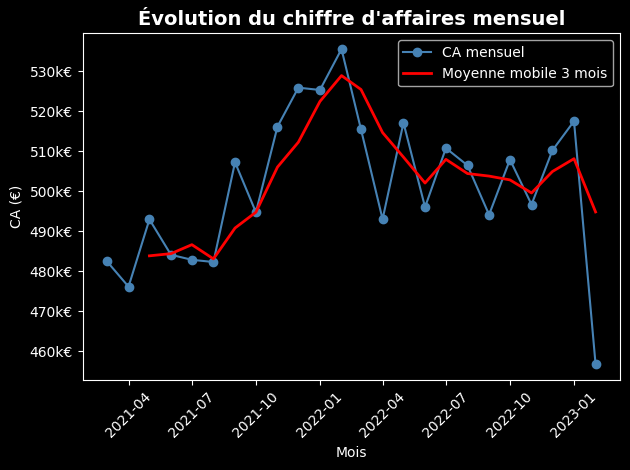

In [25]:
ca_mensuel = df.groupby("year_month")["price"].sum()
ca_mensuel.index = ca_mensuel.index.to_timestamp()

mm3 = ca_mensuel.rolling(window=3, center=False).mean()

fig, ax = plt.subplots()
ax.plot(ca_mensuel.index, ca_mensuel.values, marker="o", color="steelblue", linewidth=1.5, label="CA mensuel")
ax.plot(mm3.index, mm3.values, color="red", linewidth=2, label="Moyenne mobile 3 mois")
ax.set_title("Évolution du chiffre d'affaires mensuel", fontsize=14, fontweight="bold")
ax.set_xlabel("Mois")
ax.set_ylabel("CA (€)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k€"))
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("graph_01_ca_mensuel.png", dpi=150)
plt.show()

### Décomposition temporelle

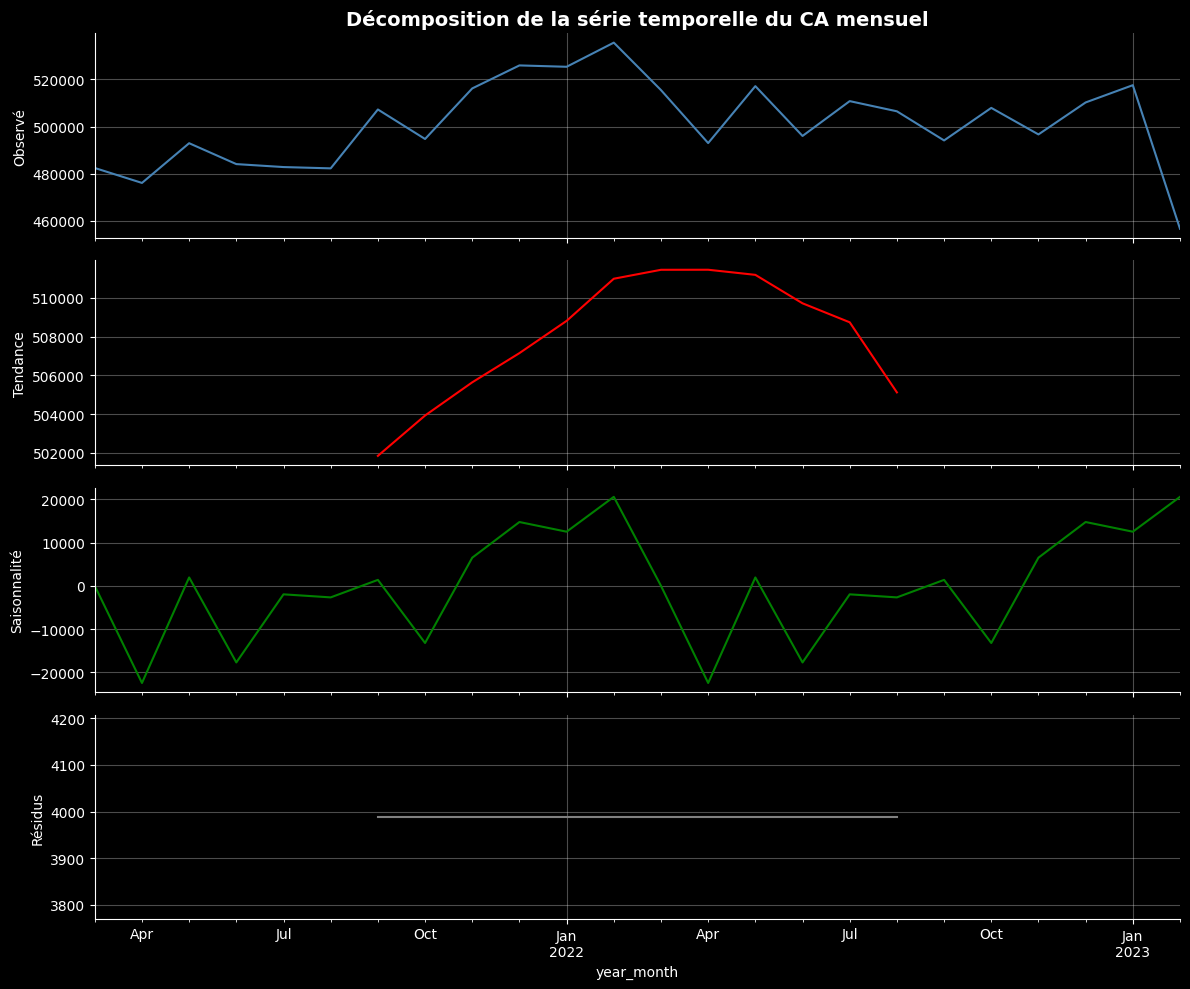

In [26]:
ca_mensuel_ts = ca_mensuel.copy()
ca_mensuel_ts = ca_mensuel_ts.asfreq("MS")  # fréquence mensuelle explicite

decomposition = seasonal_decompose(ca_mensuel_ts, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

decomposition.observed.plot(ax=axes[0], color="steelblue")
axes[0].set_ylabel("Observé")
axes[0].set_title("Décomposition de la série temporelle du CA mensuel",
                  fontsize=14, fontweight="bold")

decomposition.trend.plot(ax=axes[1], color="red")
axes[1].set_ylabel("Tendance")

decomposition.seasonal.plot(ax=axes[2], color="green")
axes[2].set_ylabel("Saisonnalité")

decomposition.resid.plot(ax=axes[3], color="gray")
axes[3].set_ylabel("Résidus")

for ax in axes:
    ax.grid(alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("graph_02_decomposition_ts.png", dpi=150)
plt.show()

### Catégories

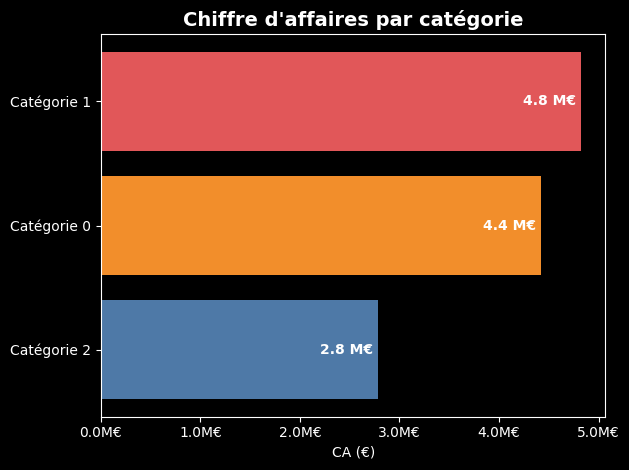

In [27]:
ca_categ = df.groupby("categ_label")["price"].sum().sort_values(ascending=True)

fig, ax = plt.subplots()
bars = ax.barh(ca_categ.index, ca_categ.values, color=["#4e79a7", "#f28e2b", "#e15759"])
for bar, val in zip(bars, ca_categ.values):
    ax.text(bar.get_width() - 50000, bar.get_y() + bar.get_height()/2,
            f"{val/1e6:.1f} M€", va="center", ha="right", fontweight="bold", color="white")
ax.set_title("Chiffre d'affaires par catégorie", fontsize=14, fontweight="bold")
ax.set_xlabel("CA (€)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M€"))
plt.tight_layout()
plt.savefig("graph_02_ca_categorie.png", dpi=150)
plt.show()

### Catégories temporelles

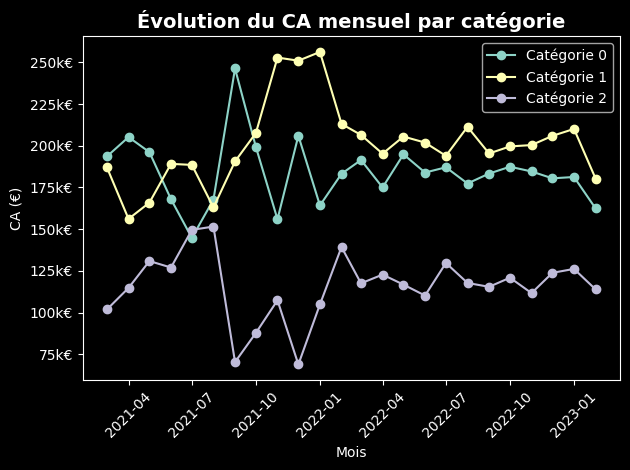

In [28]:
ca_categ_mois = df.groupby(["year_month", "categ_label"])["price"].sum().unstack(fill_value=0)
ca_categ_mois.index = ca_categ_mois.index.to_timestamp()

fig, ax = plt.subplots()
for col in ca_categ_mois.columns:
    ax.plot(ca_categ_mois.index, ca_categ_mois[col], marker="o", linewidth=1.5, label=col)
ax.set_title("Évolution du CA mensuel par catégorie", fontsize=14, fontweight="bold")
ax.set_xlabel("Mois")
ax.set_ylabel("CA (€)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k€"))
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("graph_13_ca_categorie_temps.png", dpi=150)
plt.show()

### Clients uniques mensuels

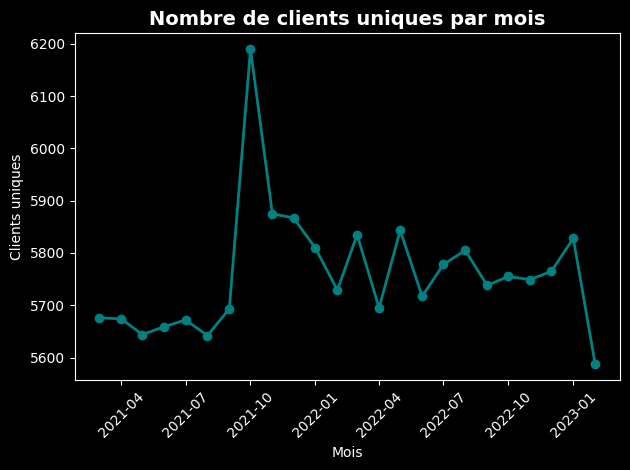

In [29]:
clients_mois = df.groupby("year_month")["client_id"].nunique()
clients_mois.index = clients_mois.index.to_timestamp()

fig, ax = plt.subplots()
ax.plot(clients_mois.index, clients_mois.values, marker="o", color="teal", linewidth=2)
ax.set_title("Nombre de clients uniques par mois", fontsize=14, fontweight="bold")
ax.set_xlabel("Mois")
ax.set_ylabel("Clients uniques")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("graph_03_clients_mois.png", dpi=150)
plt.show()

### Panier moyen

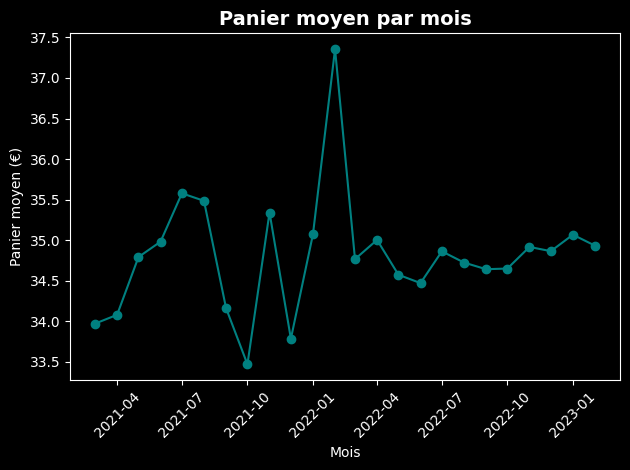

Panier moyen global : 34.81 €


In [30]:
ca_mois = df.groupby("year_month")["price"].sum()
sessions_mois = df.groupby("year_month")["session_id"].nunique()
panier_moyen_mois = ca_mois / sessions_mois
panier_moyen_mois.index = panier_moyen_mois.index.to_timestamp()

fig, ax = plt.subplots()
ax.plot(panier_moyen_mois.index, panier_moyen_mois.values, marker="o",
        color="teal", linewidth=1.5)
ax.set_title("Panier moyen par mois", fontsize=14, fontweight="bold")
ax.set_xlabel("Mois")
ax.set_ylabel("Panier moyen (€)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("graph_14_panier_moyen_mois.png", dpi=150)
plt.show()

print(f"Panier moyen global : {df['price'].sum() / df['session_id'].nunique():.2f} €")

### Transactions mensuelles

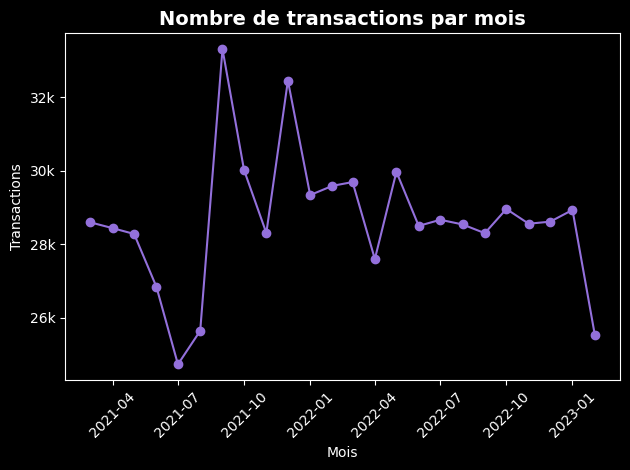

In [31]:
tx_mois = df.groupby("year_month").size()
tx_mois.index = tx_mois.index.to_timestamp()

fig, ax = plt.subplots()
ax.plot(tx_mois.index, tx_mois.values, marker="o", color="mediumpurple", linewidth=1.5)
ax.set_title("Nombre de transactions par mois", fontsize=14, fontweight="bold")
ax.set_xlabel("Mois")
ax.set_ylabel("Transactions")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("graph_04_transactions_mois.png", dpi=150)
plt.show()

### Ventes mensuelles de référence de produit

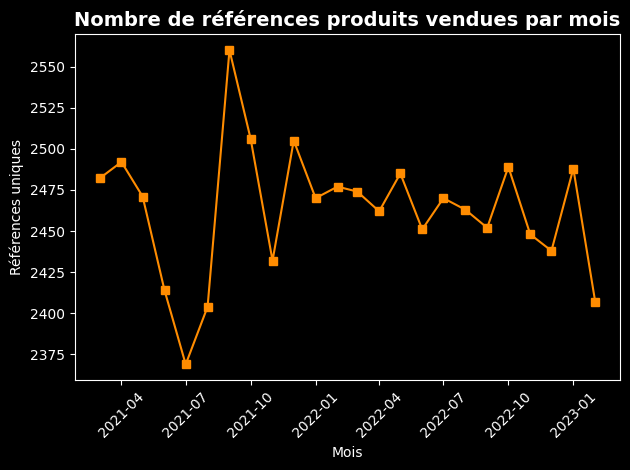

In [32]:
prods_mois = df.groupby("year_month")["id_prod"].nunique()
prods_mois.index = prods_mois.index.to_timestamp()

fig, ax = plt.subplots()
ax.plot(prods_mois.index, prods_mois.values, marker="s", color="darkorange", linewidth=1.5)
ax.set_title("Nombre de références produits vendues par mois", fontsize=14, fontweight="bold")
ax.set_xlabel("Mois")
ax.set_ylabel("Références uniques")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("graph_05_produits_mois.png", dpi=150)
plt.show()

## Références

### Tops

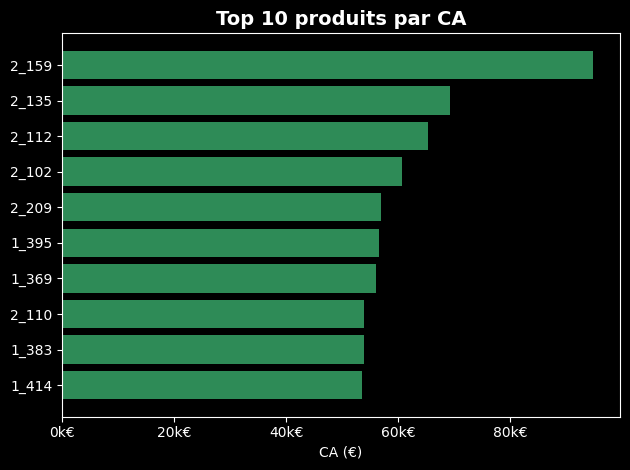


Top 10 produits :
id_prod  ca_total  nb_ventes  prix_unitaire  categ
  2_159  94893.50        650         145.99      2
  2_135  69334.95       1005          68.99      2
  2_112  65407.76        968          67.57      2
  2_102  60736.78       1027          59.14      2
  2_209  56971.86        814          69.99      2
  1_395  56617.47       1953          28.99      1
  1_369  56136.60       2340          23.99      1
  2_110  53846.25        865          62.25      2
  1_383  53834.43       1857          28.99      1
  1_414  53522.18       2246          23.83      1


In [33]:
ca_par_produit = df.groupby("id_prod")["price"].agg(["sum", "count"]).rename(
    columns={"sum": "ca_total", "count": "nb_ventes"})
ca_par_produit = ca_par_produit.merge(products[["id_prod", "price", "categ"]], on="id_prod")
ca_par_produit.rename(columns={"price": "prix_unitaire"}, inplace=True)

# Top 10
top10 = ca_par_produit.nlargest(10, "ca_total")
fig, ax = plt.subplots()
bars = ax.barh(top10["id_prod"], top10["ca_total"], color="seagreen")
ax.set_title("Top 10 produits par CA", fontsize=14, fontweight="bold")
ax.set_xlabel("CA (€)")
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k€"))
plt.tight_layout()
plt.savefig("graph_06_top10_produits.png", dpi=150)
plt.show()

print("\nTop 10 produits :")
print(top10[["id_prod", "ca_total", "nb_ventes", "prix_unitaire", "categ"]].to_string(index=False))

### Flops

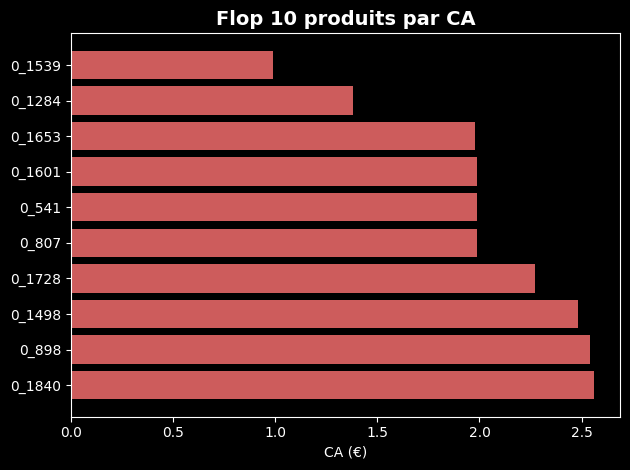


Flop 10 produits :
id_prod  ca_total  nb_ventes  prix_unitaire  categ
 0_1539      0.99          1           0.99      0
 0_1284      1.38          1           1.38      0
 0_1653      1.98          2           0.99      0
 0_1601      1.99          1           1.99      0
  0_541      1.99          1           1.99      0
  0_807      1.99          1           1.99      0
 0_1728      2.27          1           2.27      0
 0_1498      2.48          1           2.48      0
  0_898      2.54          2           1.27      0
 0_1840      2.56          2           1.28      0


In [34]:
flop10 = ca_par_produit.nsmallest(10, "ca_total")
fig, ax = plt.subplots()
bars = ax.barh(flop10["id_prod"], flop10["ca_total"], color="indianred")
ax.set_title("Flop 10 produits par CA", fontsize=14, fontweight="bold")
ax.set_xlabel("CA (€)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("graph_07_flop10_produits.png", dpi=150)
plt.show()

print("\nFlop 10 produits :")
print(flop10[["id_prod", "ca_total", "nb_ventes", "prix_unitaire", "categ"]].to_string(index=False))

### Analyse Pareto

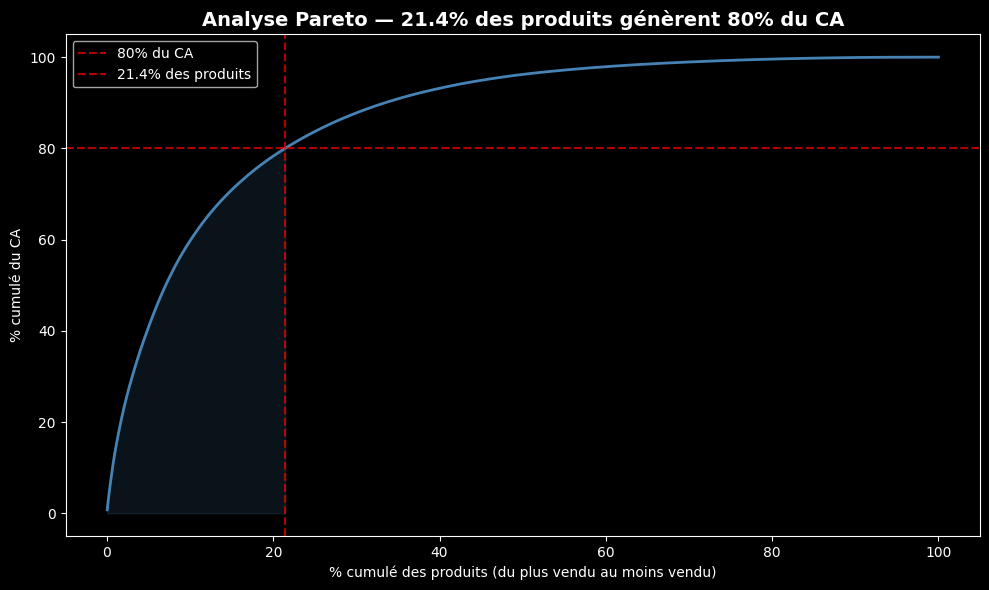

21.4% des produits génèrent 80% du CA
Soit 700 produits sur 3265


In [35]:
ca_produit = df.groupby("id_prod")["price"].sum().sort_values(ascending=False)
ca_produit_cumule_pct = ca_produit.cumsum() / ca_produit.sum() * 100
produits_pct = np.arange(1, len(ca_produit_cumule_pct) + 1) / len(ca_produit_cumule_pct) * 100

# Trouver le seuil 80%
idx_80 = np.argmax(ca_produit_cumule_pct.values >= 80)
pct_produits_80 = produits_pct[idx_80]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(produits_pct, ca_produit_cumule_pct.values, color="steelblue", linewidth=2)
ax.axhline(y=80, color="red", linestyle="--", alpha=0.7, label=f"80% du CA")
ax.axvline(x=pct_produits_80, color="red", linestyle="--", alpha=0.7,
           label=f"{pct_produits_80:.1f}% des produits")
ax.fill_between(produits_pct[:idx_80+1], ca_produit_cumule_pct.values[:idx_80+1],
                alpha=0.15, color="steelblue")
ax.set_title(f"Analyse Pareto — {pct_produits_80:.1f}% des produits génèrent 80% du CA",
             fontsize=14, fontweight="bold")
ax.set_xlabel("% cumulé des produits (du plus vendu au moins vendu)")
ax.set_ylabel("% cumulé du CA")
ax.legend()
plt.tight_layout()
plt.savefig("graph_15_pareto_produits.png", dpi=150)
plt.show()

print(f"{pct_produits_80:.1f}% des produits génèrent 80% du CA")
print(f"Soit {idx_80 + 1} produits sur {len(ca_produit)}")

### Répartition par catégorie

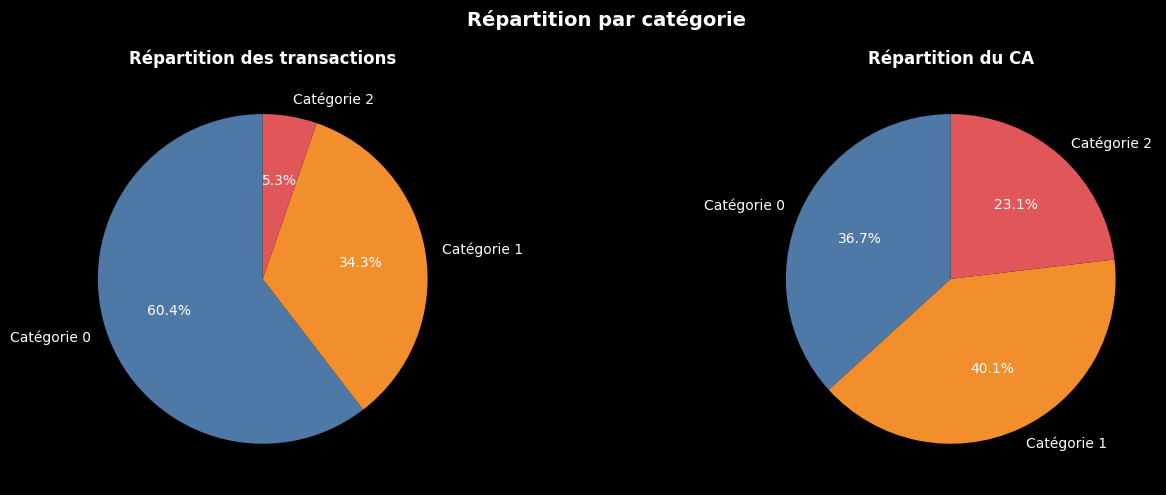

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Par nombre de transactions
tx_categ = df["categ_label"].value_counts()
axes[0].pie(tx_categ.values, labels=tx_categ.index, autopct="%1.1f%%",
            colors=["#4e79a7", "#f28e2b", "#e15759"], startangle=90)
axes[0].set_title("Répartition des transactions", fontweight="bold")

# Par CA
ca_categ_pie = df.groupby("categ_label")["price"].sum()
axes[1].pie(ca_categ_pie.values, labels=ca_categ_pie.index, autopct="%1.1f%%",
            colors=["#4e79a7", "#f28e2b", "#e15759"], startangle=90)
axes[1].set_title("Répartition du CA", fontweight="bold")

plt.suptitle("Répartition par catégorie", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("graph_08_repartition_categorie.png", dpi=150)
plt.show()

### Produits jamais vendus


--- 21 produits jamais vendus ---

Répartition par catégorie :
categ
0    16
1     2
2     3

Statistiques de prix :
count     21.00
mean      37.87
std       56.62
min        0.80
25%        2.99
50%       22.05
75%       31.82
max      220.99

Comparaison avec les produits vendus :
  Prix moyen (jamais vendus) : 37.87 €
  Prix moyen (vendus)        : 21.76 €


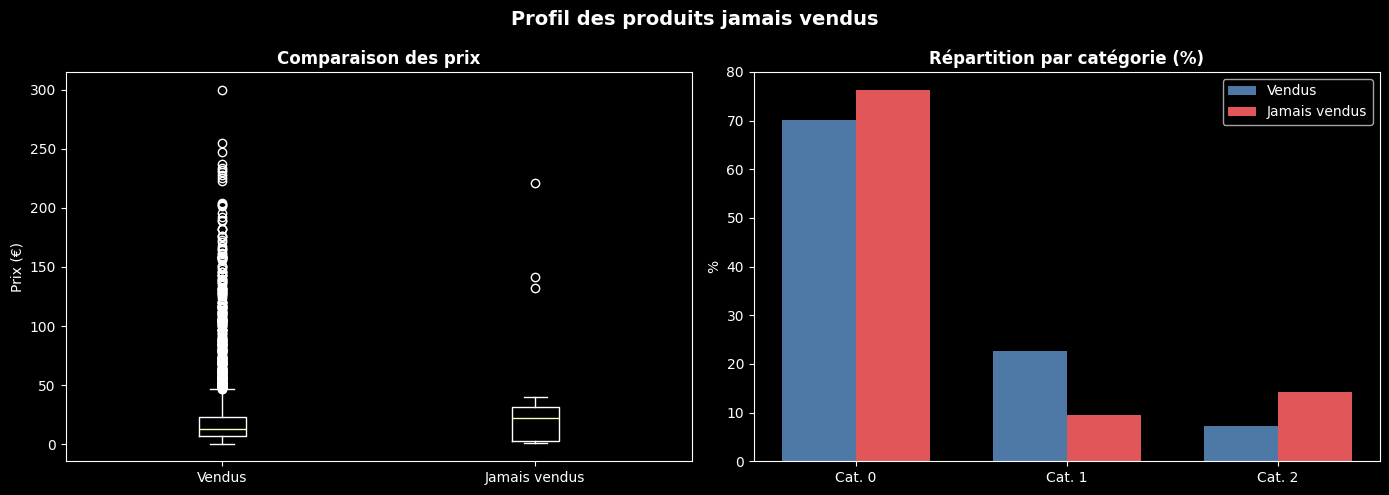

In [37]:
prods_jamais = products[~products["id_prod"].isin(df["id_prod"])]
print("\n--- 21 produits jamais vendus ---")
print(f"\nRépartition par catégorie :")
print(prods_jamais["categ"].value_counts().sort_index().to_string())
print(f"\nStatistiques de prix :")
print(prods_jamais["price"].describe().round(2).to_string())
print(f"\nComparaison avec les produits vendus :")
print(f"  Prix moyen (jamais vendus) : {prods_jamais['price'].mean():.2f} €")
print(f"  Prix moyen (vendus)        : {products[products['id_prod'].isin(df['id_prod'])]['price'].mean():.2f} €")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prix des produits jamais vendus vs vendus
axes[0].boxplot([products[products["id_prod"].isin(df["id_prod"])]["price"],
                 prods_jamais["price"]],
                tick_labels=["Vendus", "Jamais vendus"])
axes[0].set_title("Comparaison des prix", fontweight="bold")
axes[0].set_ylabel("Prix (€)")

# Répartition catégorie des jamais vendus
categ_jamais = prods_jamais["categ"].value_counts().sort_index()
categ_vendus = products[products["id_prod"].isin(df["id_prod"])]["categ"].value_counts(normalize=True).sort_index() * 100
categ_jamais_pct = prods_jamais["categ"].value_counts(normalize=True).sort_index() * 100

x = np.arange(3)
w = 0.35
axes[1].bar(x - w/2, categ_vendus.values, w, label="Vendus", color="#4e79a7")
axes[1].bar(x + w/2, categ_jamais_pct.values, w, label="Jamais vendus", color="#e15759")
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"Cat. {i}" for i in range(3)])
axes[1].set_title("Répartition par catégorie (%)", fontweight="bold")
axes[1].set_ylabel("%")
axes[1].legend()

plt.suptitle("Profil des produits jamais vendus", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("graph_17_produits_jamais_vendus.png", dpi=150)
plt.show()

## Profils clients

### Distribution par âge et sexe

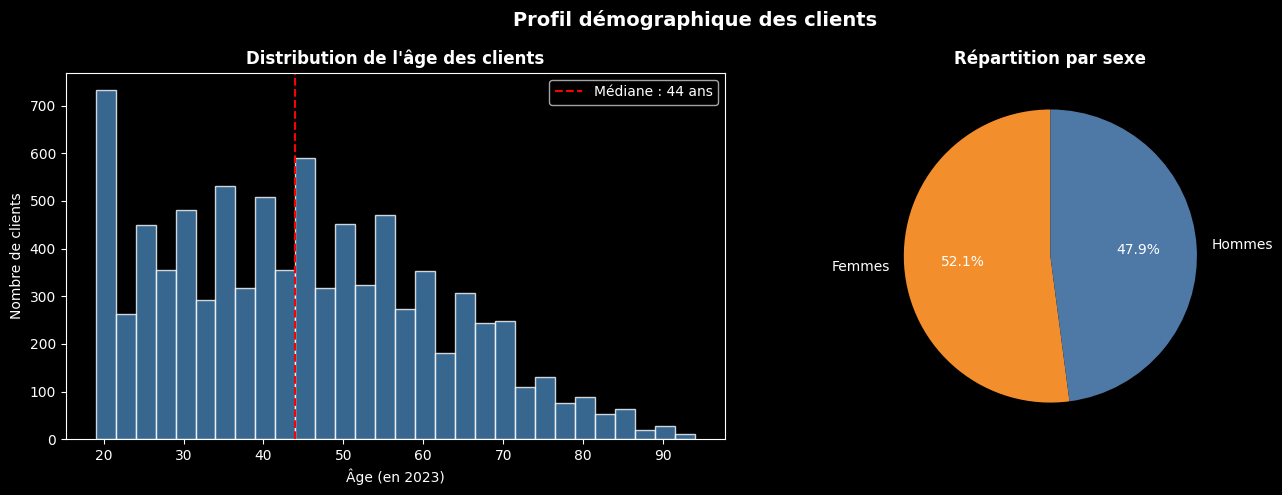


--- CA par sexe ---
               sum   count   mean
sex                              
Femmes  5950843.68  342693  17.36
Hommes  6076819.42  344841  17.62


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

age_ref = 2023 - customers["birth"]
axes[0].hist(age_ref, bins=30, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].set_title("Distribution de l'âge des clients", fontweight="bold")
axes[0].set_xlabel("Âge (en 2023)")
axes[0].set_ylabel("Nombre de clients")
axes[0].axvline(age_ref.median(), color="red", linestyle="--",
                label=f"Médiane : {age_ref.median():.0f} ans")
axes[0].legend()

sex_counts = customers["sex"].value_counts()
sex_labels = {"f": "Femmes", "m": "Hommes"}
axes[1].pie([sex_counts["f"], sex_counts["m"]],
            labels=[sex_labels["f"], sex_labels["m"]],
            autopct="%1.1f%%",
            colors=["#f28e2b", "#4e79a7"],
            startangle=90)
axes[1].set_title("Répartition par sexe", fontweight="bold")

plt.suptitle("Profil démographique des clients", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("graph_16_profil_clients.png", dpi=150)
plt.show()

ca_sex = df.groupby("sex")["price"].agg(["sum", "count", "mean"]).round(2)
ca_sex.index = ca_sex.index.map(sex_labels)
print("\n--- CA par sexe ---")
print(ca_sex.to_string())

### Clients sans achat


--- 21 clients sans aucun achat ---

Répartition par sexe :
sex
f    11
m    10

Âge moyen (en 2023) : 38.6 ans
Âge moyen (clients actifs) : 44.7 ans


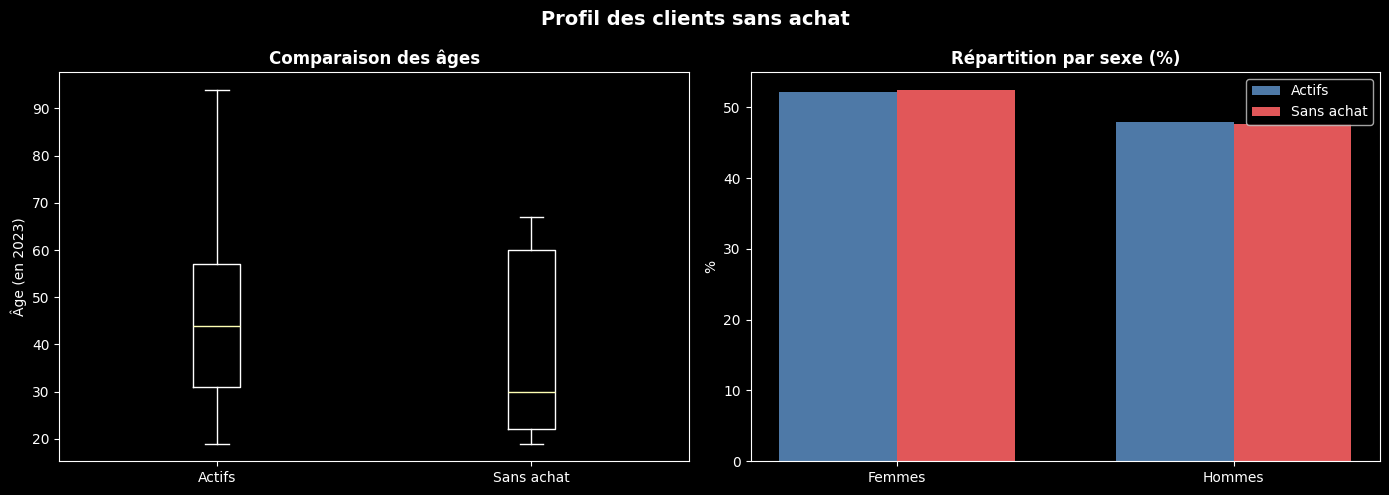

In [39]:
clients_sans = customers[~customers["client_id"].isin(df["client_id"])]
print("\n--- 21 clients sans aucun achat ---")
print(f"\nRépartition par sexe :")
print(clients_sans["sex"].value_counts().to_string())
print(f"\nÂge moyen (en 2023) : {(2023 - clients_sans['birth']).mean():.1f} ans")
print(f"Âge moyen (clients actifs) : {(2023 - customers[customers['client_id'].isin(df['client_id'])]['birth']).mean():.1f} ans")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

age_actifs = 2023 - customers[customers["client_id"].isin(df["client_id"])]["birth"]
age_inactifs = 2023 - clients_sans["birth"]
axes[0].boxplot([age_actifs, age_inactifs], tick_labels=["Actifs", "Sans achat"])
axes[0].set_title("Comparaison des âges", fontweight="bold")
axes[0].set_ylabel("Âge (en 2023)")

sex_actifs_pct = customers[customers["client_id"].isin(df["client_id"])]["sex"].value_counts(normalize=True) * 100
sex_inactifs_pct = clients_sans["sex"].value_counts(normalize=True) * 100
x = np.arange(2)
axes[1].bar(x - w / 2, [sex_actifs_pct.get("f", 0), sex_actifs_pct.get("m", 0)],
            w, label="Actifs", color="#4e79a7")
axes[1].bar(x + w / 2, [sex_inactifs_pct.get("f", 0), sex_inactifs_pct.get("m", 0)],
            w, label="Sans achat", color="#e15759")
axes[1].set_xticks(x)
axes[1].set_xticklabels(["Femmes", "Hommes"])
axes[1].set_title("Répartition par sexe (%)", fontweight="bold")
axes[1].set_ylabel("%")
axes[1].legend()

plt.suptitle("Profil des clients sans achat", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("graph_18_clients_sans_achat.png", dpi=150)
plt.show()

### Courbe de Lorentz

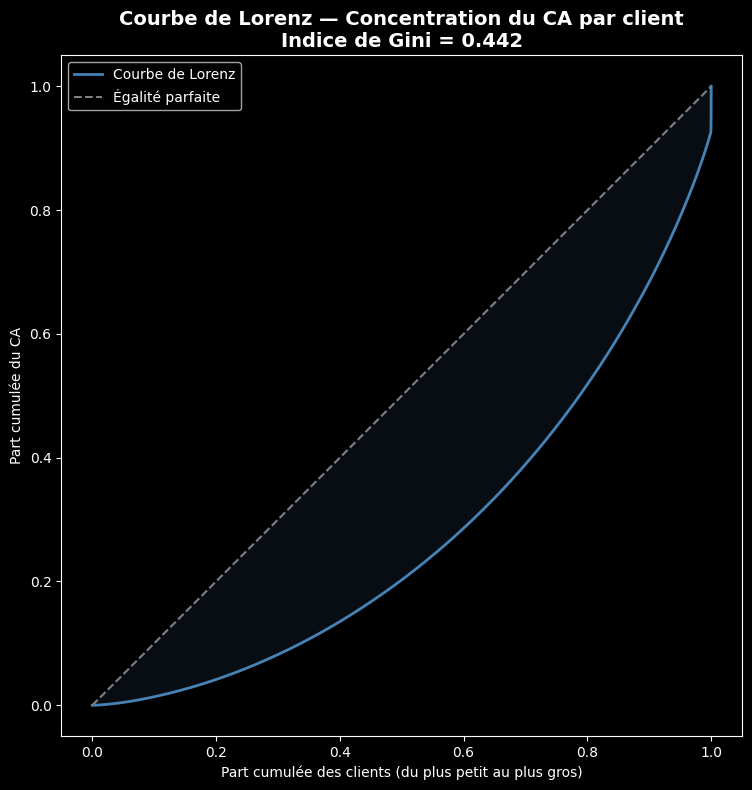

Indice de Gini : 0.442
Top 1% des clients → 10.5% du CA
Top 5% des clients → 21.0% du CA
Top 10% des clients → 31.6% du CA
Top 20% des clients → 48.1% du CA

--- Top 10 clients par CA total ---
            ca_total  nb_achats  nb_sessions
client_id                                   
c_1609     326039.89      25586        10997
c_4958     290227.03       5222         3851
c_6714     153918.60       9199         2620
c_3454     114110.57       6793         5571
c_1570       5285.82        370          159
c_3263       5276.87        403          143
c_2140       5260.18        405          147
c_2899       5214.05        105           69
c_7319       5155.77        371          145
c_7959       5135.75        372          148


In [40]:

ca_par_client = df.groupby("client_id")["price"].sum().sort_values().values
ca_cumule = np.cumsum(ca_par_client)
ca_cumule_pct = ca_cumule / ca_cumule[-1]  # en % du CA total
clients_pct = np.arange(1, len(ca_cumule_pct) + 1) / len(ca_cumule_pct)

# Indice de Gini (aire entre la diagonale et la courbe)
gini = 1 - 2 * np.trapezoid(ca_cumule_pct, clients_pct)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(clients_pct, ca_cumule_pct, color="steelblue", linewidth=2, label="Courbe de Lorenz")
ax.plot([0, 1], [0, 1], "--", color="gray", label="Égalité parfaite")
ax.fill_between(clients_pct, ca_cumule_pct, clients_pct,
                alpha=0.1, color="steelblue")
ax.set_title(f"Courbe de Lorenz — Concentration du CA par client\nIndice de Gini = {gini:.3f}",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Part cumulée des clients (du plus petit au plus gros)")
ax.set_ylabel("Part cumulée du CA")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("graph_10_lorenz.png", dpi=150)
plt.show()

# --- Lecture de la Lorenz : quelques repères ---
print(f"Indice de Gini : {gini:.3f}")
# Quel % du CA est généré par le top 1%, 5%, 10% des clients ?
for pct in [1, 5, 10, 20]:
    seuil_idx = int(len(ca_par_client) * (1 - pct/100))
    part_ca = ca_par_client[seuil_idx:].sum() / ca_par_client.sum() * 100
    print(f"Top {pct}% des clients → {part_ca:.1f}% du CA")

# --- Les plus gros clients (ceux qui tirent la courbe) ---
print("\n--- Top 10 clients par CA total ---")
top_clients = df.groupby("client_id").agg(
    ca_total=("price", "sum"),
    nb_achats=("id_prod", "count"),
    nb_sessions=("session_id", "nunique")
).nlargest(10, "ca_total")
print(top_clients.to_string())

En observant le CA par client et le volume à la fois des transactions et des sessions, les clients BtoB sont facilement identifiables comme étant c_1609, c_4958, c_6714 et c_3454

### Répartition du Chiffre d'Affaires pour les clients BtoB

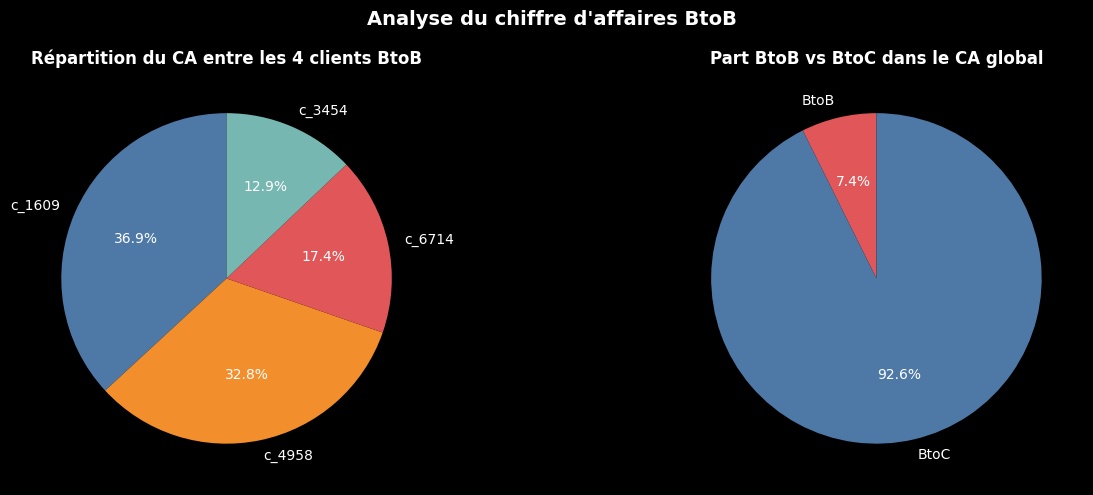

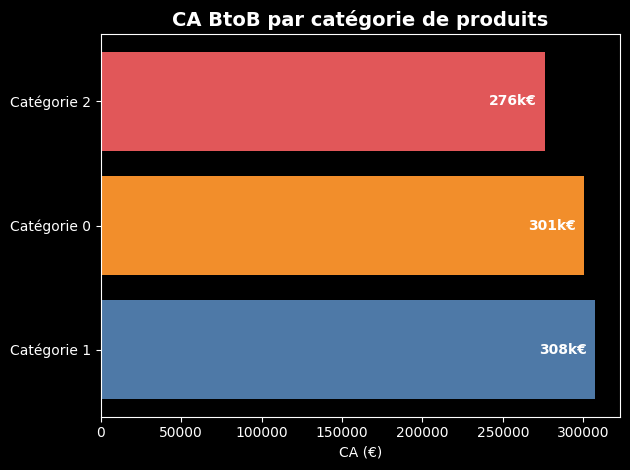


--- Résumé BtoB ---
CA BtoB total : 884,296.09 € (7.4% du CA global)
CA BtoC total : 11,143,367.01 €

CA BtoB par catégorie :
  Catégorie 1 : 307,555.25 € (34.8%)
  Catégorie 0 : 300,530.28 € (34.0%)
  Catégorie 2 : 276,210.56 € (31.2%)


In [41]:
clients_btob = ["c_1609", "c_4958", "c_6714", "c_3454"]
df_btob = df[df["client_id"].isin(clients_btob)]

# --- Répartition du CA BtoB par client ---
ca_btob_client = df_btob.groupby("client_id")["price"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Camembert : part de chaque client BtoB
axes[0].pie(ca_btob_client.values,
            labels=ca_btob_client.index,
            autopct="%1.1f%%",
            colors=["#4e79a7", "#f28e2b", "#e15759", "#76b7b2"],
            startangle=90)
axes[0].set_title("Répartition du CA entre les 4 clients BtoB", fontweight="bold")

# Camembert : part BtoB vs BtoC dans le CA global
ca_btob_total = df_btob["price"].sum()
ca_btoc_total = df["price"].sum() - ca_btob_total
axes[1].pie([ca_btob_total, ca_btoc_total],
            labels=["BtoB", "BtoC"],
            autopct="%1.1f%%",
            colors=["#e15759", "#4e79a7"],
            startangle=90)
axes[1].set_title("Part BtoB vs BtoC dans le CA global", fontweight="bold")

plt.suptitle("Analyse du chiffre d'affaires BtoB", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("graph_11_ca_btob.png", dpi=150)
plt.show()

# --- Répartition du CA BtoB par catégorie ---
ca_btob_categ = df_btob.groupby("categ_label")["price"].sum().sort_values(ascending=False)

fig, ax = plt.subplots()
bars = ax.barh(ca_btob_categ.index, ca_btob_categ.values,
               color=["#4e79a7", "#f28e2b", "#e15759"])
for bar, val in zip(bars, ca_btob_categ.values):
    ax.text(bar.get_width() - 5000, bar.get_y() + bar.get_height()/2,
            f"{val/1e3:.0f}k€", va="center", ha="right", fontweight="bold", color="white")
ax.set_title("CA BtoB par catégorie de produits", fontsize=14, fontweight="bold")
ax.set_xlabel("CA (€)")
plt.tight_layout()
plt.savefig("graph_12_ca_btob_categorie.png", dpi=150)
plt.show()

# --- Résumé chiffré ---
print("\n--- Résumé BtoB ---")
print(f"CA BtoB total : {ca_btob_total:,.2f} € ({ca_btob_total/df['price'].sum()*100:.1f}% du CA global)")
print(f"CA BtoC total : {ca_btoc_total:,.2f} €")
print(f"\nCA BtoB par catégorie :")
for cat, val in ca_btob_categ.items():
    print(f"  {cat} : {val:,.2f} € ({val/ca_btob_total*100:.1f}%)")

# RÉCAP POUR LE PPT

In [42]:
print(f"Période analysée         : {df['date'].min().date()} → {df['date'].max().date()} (24 mois)")
print(f"CA total                 : {df['price'].sum():,.2f} €")
print(f"CA mensuel moyen         : {df['price'].sum() / 24:,.2f} €")
print(f"Transactions totales     : {len(df):,}")
print(f"Transactions / mois moy. : {len(df) / 24:,.0f}")
print(f"Clients uniques          : {df['client_id'].nunique():,}")
print(f"Produits uniques vendus  : {df['id_prod'].nunique():,}")
print(f"Panier moyen (session)   : {df['price'].sum() / df['session_id'].nunique():.2f} €")
print(f"Prix moyen par article   : {df['price'].mean():.2f} €")
print(f"Indice de Gini           : {gini:.3f}")
print(f"Part BtoB dans le CA     : {ca_btob_total / df['price'].sum() * 100:.1f}%")
print(f"Clients BtoB identifiés  : 4")
print(f"Produits jamais vendus   : 21")
print(f"Clients sans achat       : 21")

Période analysée         : 2021-03-01 → 2023-02-28 (24 mois)
CA total                 : 12,027,663.10 €
CA mensuel moyen         : 501,152.63 €
Transactions totales     : 687,534
Transactions / mois moy. : 28,647
Clients uniques          : 8,600
Produits uniques vendus  : 3,265
Panier moyen (session)   : 34.81 €
Prix moyen par article   : 17.49 €
Indice de Gini           : 0.442
Part BtoB dans le CA     : 7.4%
Clients BtoB identifiés  : 4
Produits jamais vendus   : 21
Clients sans achat       : 21


# Tests Statistiques

## Préparation des données

On reprend le chargement et la fusion des données pour s'assurer d'une non-pollution par l'étape d'analyse

In [43]:
products = pd.read_csv(".\\Data\\products.csv", sep=";")
customers = pd.read_csv(".\\Data\\customers.csv", sep=";")
transactions = pd.read_csv(".\\Data\\Transactions.csv", sep=";", low_memory=False)
transactions = transactions.dropna(how="all")
transactions["date"] = pd.to_datetime(transactions["date"])
df = transactions.merge(products, on="id_prod", how="left") \
                 .merge(customers, on="client_id", how="left")
df["year_month"] = df["date"].dt.to_period("M")
df["age"] = df["date"].dt.year - df["birth"]
categ_labels = {0: "Catégorie 0", 1: "Catégorie 1", 2: "Catégorie 2"}
df["categ_label"] = df["categ"].map(categ_labels)

On exclut les clients BtoB

In [44]:
clients_btob = ["c_1609", "c_4958", "c_6714", "c_3454"]
df_btoc = df[~df["client_id"].isin(clients_btob)].copy()

print(f"Transactions avant exclusion BtoB  : {len(df):,}")
print(f"Transactions après exclusion BtoB  : {len(df_btoc):,}")
print(f"Transactions exclues               : {len(df) - len(df_btoc):,}")
print(f"Clients restants                   : {df_btoc['client_id'].nunique():,}")

Transactions avant exclusion BtoB  : 687,534
Transactions après exclusion BtoB  : 640,734
Transactions exclues               : 46,800
Clients restants                   : 8,596


On aggrège les données autour d'un client car travailler avec des transactions donnerait plus de poids à un client plus actif. Tout comme les "merge", ceci fait disparaître les 21 clients sans achat

In [45]:
clients_agg = df_btoc.groupby("client_id").agg(
    ca_total=("price", "sum"),
    nb_achats=("id_prod", "count"),
    nb_sessions=("session_id", "nunique"),
    age_moyen=("age", "mean"),  # âge moyen sur la période (varie peu)
    sex=("sex", "first")
).reset_index()

# Panier moyen = CA / nombre de sessions (pas transactions)
clients_agg["panier_moyen"] = clients_agg["ca_total"] / clients_agg["nb_sessions"]

# Fréquence = nombre de sessions sur la période
clients_agg["frequence"] = clients_agg["nb_sessions"]

print(f"\n--- Aperçu données agrégées par client ---")
print(clients_agg.describe().round(2).to_string())


--- Aperçu données agrégées par client ---
       ca_total  nb_achats  nb_sessions  age_moyen  panier_moyen  frequence
count   8596.00    8596.00      8596.00    8596.00       8596.00    8596.00
mean    1296.34      74.54        37.51      43.38         40.40      37.51
std      958.40      68.07        30.90      16.91         22.76      30.90
min        6.31       1.00         1.00      17.00          4.15       1.00
25%      562.64      28.00        15.00      29.57         25.76      15.00
50%     1045.58      52.00        27.00      42.48         32.34      27.00
75%     1796.02      97.00        50.00      55.55         48.31      50.00
max     5285.82     405.00       167.00      92.90        259.42     167.00


## Sexe et catégorie


--- Tableau de contingence Genre × Catégorie dominante ---
categ_dom_label  Catégorie 0  Catégorie 1  Catégorie 2
sex                                                   
f                       2370         1608          500
m                       2256         1385          477


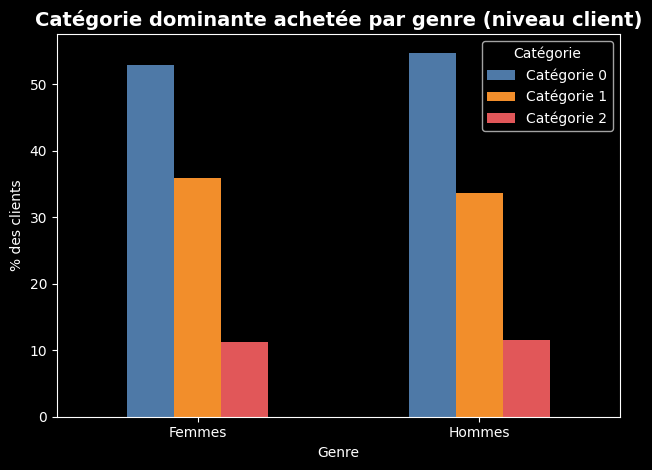


Test du Chi² d'indépendance :
  Chi²     = 4.8977
  p-value  = 8.6393e-02
  ddl      = 2
  → Non-rejet de H0 : pas de lien significatif (seuil 5%)


In [46]:
# Catégorie dominante par client
categ_dominante = df_btoc.groupby("client_id")["categ"].agg(lambda x: x.mode()[0])
clients_agg = clients_agg.merge(categ_dominante.rename("categ_dominante"), on="client_id")
clients_agg["categ_dom_label"] = clients_agg["categ_dominante"].map(categ_labels)

# Tableau de contingence au niveau client
contingence = pd.crosstab(clients_agg["sex"], clients_agg["categ_dom_label"])
print("\n--- Tableau de contingence Genre × Catégorie dominante ---")
print(contingence.to_string())

# Graphique bivarié : barres groupées (proportions)
contingence_pct = pd.crosstab(clients_agg["sex"], clients_agg["categ_dom_label"],
                              normalize="index") * 100

fig, ax = plt.subplots()
contingence_pct.plot(kind="bar", ax=ax, color=["#4e79a7", "#f28e2b", "#e15759"])
ax.set_title("Catégorie dominante achetée par genre (niveau client)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Genre")
ax.set_ylabel("% des clients")
ax.set_xticklabels(["Femmes", "Hommes"], rotation=0)
ax.legend(title="Catégorie")
plt.tight_layout()
plt.savefig("graph_19_genre_categorie.png", dpi=150)
plt.show()

# Test du Chi²
chi2, p_chi2, dof, expected = stats.chi2_contingency(contingence)
print(f"\nTest du Chi² d'indépendance :")
print(f"  Chi²     = {chi2:.4f}")
print(f"  p-value  = {p_chi2:.4e}")
print(f"  ddl      = {dof}")
print(f"  → {'Rejet de H0 : lien significatif' if p_chi2 < 0.05 else 'Non-rejet de H0 : pas de lien significatif'} (seuil 5%)")

Pas de stratégie d'entreprise à mettre en place

## Âge et montant total


--- Test de normalité (Shapiro-Wilk) ---
  Âge      : W=0.9704, p=6.1440e-31 → Non normal
  CA total : W=0.9061, p=3.6830e-48 → Non normal


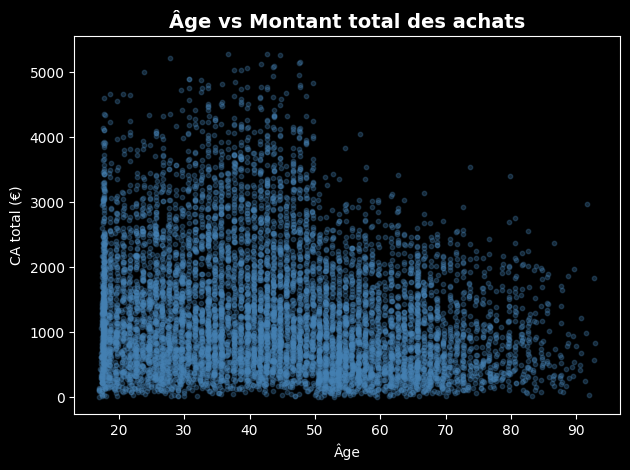


Corrélation Âge × CA total :
  Pearson  : r=-0.1858, p=1.2249e-67
  Spearman : ρ=-0.1805, p=7.6264e-64


In [47]:
np.random.seed(42)
sample = clients_agg.sample(min(5000, len(clients_agg)))
stat_age, p_norm_age = stats.shapiro(sample["age_moyen"])
stat_ca, p_norm_ca = stats.shapiro(sample["ca_total"])
print("\n--- Test de normalité (Shapiro-Wilk) ---")
print(f"  Âge      : W={stat_age:.4f}, p={p_norm_age:.4e} → {'Normal' if p_norm_age > 0.05 else 'Non normal'}")
print(f"  CA total : W={stat_ca:.4f}, p={p_norm_ca:.4e} → {'Normal' if p_norm_ca > 0.05 else 'Non normal'}")

# Graphique bivarié : scatter plot
fig, ax = plt.subplots()
ax.scatter(clients_agg["age_moyen"], clients_agg["ca_total"], alpha=0.3, s=10, color="steelblue")
ax.set_title("Âge vs Montant total des achats", fontsize=14, fontweight="bold")
ax.set_xlabel("Âge")
ax.set_ylabel("CA total (€)")
plt.tight_layout()
plt.savefig("graph_20_age_montant.png", dpi=150)
plt.show()

# Corrélations
r_pearson, p_pearson = stats.pearsonr(clients_agg["age_moyen"], clients_agg["ca_total"])
r_spearman, p_spearman = stats.spearmanr(clients_agg["age_moyen"], clients_agg["ca_total"])
print(f"\nCorrélation Âge × CA total :")
print(f"  Pearson  : r={r_pearson:.4f}, p={p_pearson:.4e}")
print(f"  Spearman : ρ={r_spearman:.4f}, p={p_spearman:.4e}")

Non normales, donc Spearman à privilégier.

p-value -> corrélation statistiquement significative, ρ -> corrélation négative faible

Les dépenses diminuent avec l'âge. Levier insuffisant pour une action entreprise

## Âge et fréquence d'achat


--- Test de normalité (Shapiro-Wilk) — Fréquence ---
  Fréquence : W=0.8577, p=2.4601e-55 → Non normal


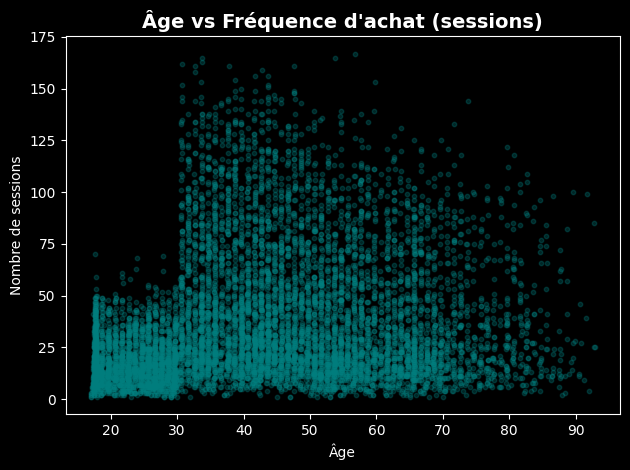


Corrélation Âge × Fréquence :
  Pearson  : r=0.1658, p=4.7659e-54
  Spearman : ρ=0.2154, p=9.5920e-91


In [48]:
sample_freq = clients_agg["frequence"].sample(min(5000, len(clients_agg)), random_state=42)
stat_freq, p_norm_freq = stats.shapiro(sample_freq)
print("\n--- Test de normalité (Shapiro-Wilk) — Fréquence ---")
print(f"  Fréquence : W={stat_freq:.4f}, p={p_norm_freq:.4e} → {'Normal' if p_norm_freq > 0.05 else 'Non normal'}")

fig, ax = plt.subplots()
ax.scatter(clients_agg["age_moyen"], clients_agg["frequence"], alpha=0.3, s=10, color="teal")
ax.set_title("Âge vs Fréquence d'achat (sessions)", fontsize=14, fontweight="bold")
ax.set_xlabel("Âge")
ax.set_ylabel("Nombre de sessions")
plt.tight_layout()
plt.savefig("graph_21_age_frequence.png", dpi=150)
plt.show()

r_pearson_f, p_pearson_f = stats.pearsonr(clients_agg["age_moyen"], clients_agg["frequence"])
r_spearman_f, p_spearman_f = stats.spearmanr(clients_agg["age_moyen"], clients_agg["frequence"])
print(f"\nCorrélation Âge × Fréquence :")
print(f"  Pearson  : r={r_pearson_f:.4f}, p={p_pearson_f:.4e}")
print(f"  Spearman : ρ={r_spearman_f:.4f}, p={p_spearman_f:.4e}")

Non normales, donc Spearman à privilégier.

p-value -> corrélation statistiquement significative, ρ -> corrélation positive faible

La fréquence augmente avec l'âge, de façon non proportionnelle. Levier insuffisant pour une action entreprise.

Ces deux dernières corrélations semblent montrer que les clients plus âgés achète plus souvent mais dépensent moins. Cela pourrait suggérer des achats plus petits mais plus régulier. Testons la corrélation entre l'âge et le panier moyen

## Âge et panier moyen


--- Test de normalité (Shapiro-Wilk) — Panier moyen ---
  Panier moyen : W=0.8126, p=2.2736e-60 → Non normal


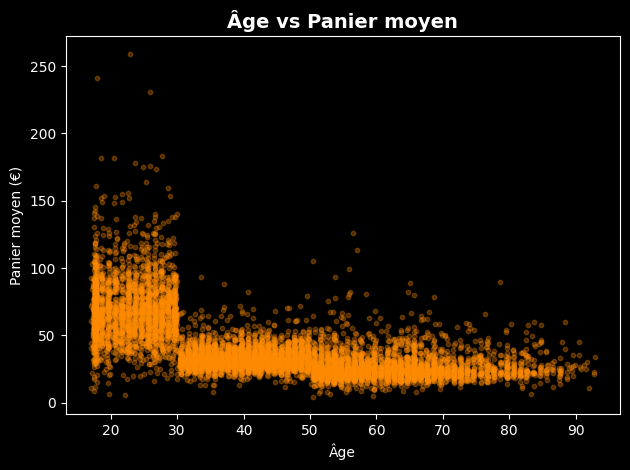


Corrélation Âge × Panier moyen :
  Pearson  : r=-0.6161, p=0.0000e+00
  Spearman : ρ=-0.6994, p=0.0000e+00


In [49]:
sample_pan = clients_agg["panier_moyen"].sample(min(5000, len(clients_agg)), random_state=42)
stat_pan, p_norm_pan = stats.shapiro(sample_pan)
print("\n--- Test de normalité (Shapiro-Wilk) — Panier moyen ---")
print(f"  Panier moyen : W={stat_pan:.4f}, p={p_norm_pan:.4e} → {'Normal' if p_norm_pan > 0.05 else 'Non normal'}")

fig, ax = plt.subplots()
ax.scatter(clients_agg["age_moyen"], clients_agg["panier_moyen"], alpha=0.3, s=10, color="darkorange")
ax.set_title("Âge vs Panier moyen", fontsize=14, fontweight="bold")
ax.set_xlabel("Âge")
ax.set_ylabel("Panier moyen (€)")
plt.tight_layout()
plt.savefig("graph_22_age_panier.png", dpi=150)
plt.show()

r_pearson_p, p_pearson_p = stats.pearsonr(clients_agg["age_moyen"], clients_agg["panier_moyen"])
r_spearman_p, p_spearman_p = stats.spearmanr(clients_agg["age_moyen"], clients_agg["panier_moyen"])
print(f"\nCorrélation Âge × Panier moyen :")
print(f"  Pearson  : r={r_pearson_p:.4f}, p={p_pearson_p:.4e}")
print(f"  Spearman : ρ={r_spearman_p:.4f}, p={p_spearman_p:.4e}")

Non normales, donc Spearman à privilégier.

p-value -> corrélation statistiquement hautement significative, ρ -> corrélation négative forte

Relation monotone non linéaire, et confirmation de l'hypothèse : les clients plus âgés achètent des produits moins cher.

Ce levier est actionnable, des offres type "pack" ciblées sur les seniors pourraient augmenter leur panier sans perdre leur fidélité.

Testons la corrélation entre l'âge et la catégorie, selon l'hypothèse actuelle, on s'attend à ce que les clients les plus âgés achètent davantage dans la catégorie la moins chère, catégorie 0.

## Âge et catégorie

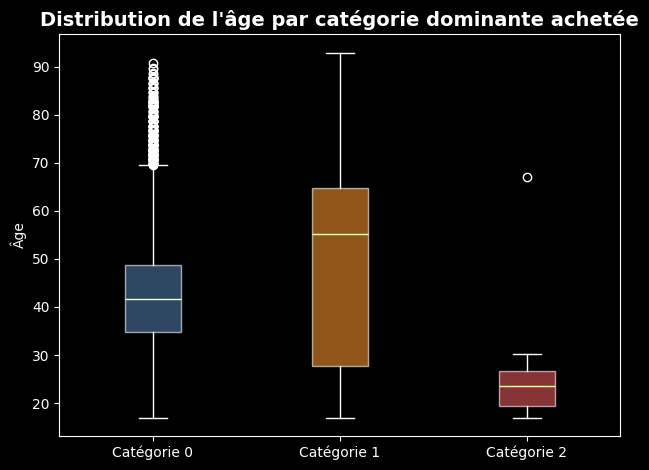


--- Âge moyen par catégorie dominante ---
                  count   mean    std   min    25%    50%    75%    max
categ_dom_label                                                        
Catégorie 0      4626.0  43.18  12.53  17.0  34.71  41.72  48.64  90.78
Catégorie 1      2993.0  50.26  19.84  17.0  27.66  55.11  64.82  92.90
Catégorie 2       977.0  23.27   4.32  17.0  19.45  23.56  26.72  67.00

--- Tests de normalité par groupe (Shapiro-Wilk) ---
  Catégorie 0 : W=0.9558, p=2.5171e-35 → Non normal
  Catégorie 1 : W=0.9106, p=8.2018e-39 → Non normal
  Catégorie 2 : W=0.8840, p=2.0834e-26 → Non normal

Test de Levene (homoscédasticité) :
  Statistique = 724.5672, p = 1.6130e-291
  → Variances non homogènes (seuil 5%)

Kruskal-Wallis (conditions ANOVA non réunies) :
  H = 1997.5653, p = 0.0000e+00
  → Rejet de H0 : différence significative (seuil 5%)

  (ANOVA à titre indicatif : F=1200.1128, p=0.0000e+00)


In [50]:
fig, ax = plt.subplots()
groups = [clients_agg[clients_agg["categ_dominante"] == c]["age_moyen"] for c in [0, 1, 2]]
bp = ax.boxplot(groups, tick_labels=["Catégorie 0", "Catégorie 1", "Catégorie 2"],
                patch_artist=True)
colors = ["#4e79a7", "#f28e2b", "#e15759"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_title("Distribution de l'âge par catégorie dominante achetée",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Âge")
plt.tight_layout()
plt.savefig("graph_23_age_categorie.png", dpi=150)
plt.show()

# Moyennes par groupe
print("\n--- Âge moyen par catégorie dominante ---")
print(clients_agg.groupby("categ_dom_label")["age_moyen"].describe().round(2).to_string())

# Vérification des conditions de l'ANOVA
# 1) Normalité par groupe (Shapiro)
print("\n--- Tests de normalité par groupe (Shapiro-Wilk) ---")
for c in [0, 1, 2]:
    group = clients_agg[clients_agg["categ_dominante"] == c]["age_moyen"]
    sample_g = group.sample(min(5000, len(group)), random_state=42)
    stat_s, p_s = stats.shapiro(sample_g)
    print(f"  Catégorie {c} : W={stat_s:.4f}, p={p_s:.4e} → {'Normal' if p_s > 0.05 else 'Non normal'}")

# 2) Homogénéité des variances (Levene)
stat_lev, p_lev = stats.levene(*groups)
print(f"\nTest de Levene (homoscédasticité) :")
print(f"  Statistique = {stat_lev:.4f}, p = {p_lev:.4e}")
print(f"  → {'Variances homogènes' if p_lev > 0.05 else 'Variances non homogènes'} (seuil 5%)")

# ANOVA ou Kruskal-Wallis selon les conditions
# On vérifie la normalité et l'homoscédasticité pour choisir
all_normal = all(
    stats.shapiro(
        clients_agg[clients_agg["categ_dominante"] == c]["age_moyen"]
        .sample(min(5000, len(clients_agg[clients_agg["categ_dominante"] == c])), random_state=42)
    ).pvalue > 0.05
    for c in [0, 1, 2]
)

if all_normal and p_lev > 0.05:
    # Conditions réunies → ANOVA paramétrique
    stat_anova, p_anova = stats.f_oneway(*groups)
    print(f"\nANOVA (conditions vérifiées) :")
    print(f"  F = {stat_anova:.4f}, p = {p_anova:.4e}")
    print(f"  → {'Rejet de H0 : différence significative' if p_anova < 0.05 else 'Non-rejet de H0 : pas de différence significative'} (seuil 5%)")
else:
    # Conditions non réunies → Kruskal-Wallis (non paramétrique)
    stat_kw, p_kw = stats.kruskal(*groups)
    print(f"\nKruskal-Wallis (conditions ANOVA non réunies) :")
    print(f"  H = {stat_kw:.4f}, p = {p_kw:.4e}")
    print(f"  → {'Rejet de H0 : différence significative' if p_kw < 0.05 else 'Non-rejet de H0 : pas de différence significative'} (seuil 5%)")
    # On fait quand même l'ANOVA pour comparaison
    stat_anova, p_anova = stats.f_oneway(*groups)
    print(f"\n  (ANOVA à titre indicatif : F={stat_anova:.4f}, p={p_anova:.4e})")

Aucune normalité ou homoscédasticité, donc Kruskal-Wallis.

p-value -> corrélation statistiquement hautement significative, ρ -> corrélation forte

La catégorie 0 est achetée par un âge moyen de 43 ans et un âge médian de 42 ans, avec un écart-type de 12.5, distribution relativement resserrée autour des "adultes"

La catégorie 1 est achetée par un âge moyen de 50 ans et un âge médian de 55 ans, avec un écart-type de 19.8, distribution très dispersée

La catégorie 2 est achetée par un âge moyen de 23 ans et un âge médian de 24 ans, avec un écart-type de 4.3, distribution très homogène sur les jeunes adultes

On a pas vraiment validation de "les clients les plus âgés achètent davantage dans la catégorie 0", présence d'outliers au-dessus de 70 ans pour la catégorie 0

Mais on a une validation de l'hypothèse complémentaire, les jeunes ont un panier moyen plus élevé car ils sont les acheteurs principaux de la catégorie la plus chère

## Conclusion

L'âge est le facteur différenciant, on a 3 profils:

Jeunes -> achètent dans la catégorie 2, panier élevé, peu fréquents

Adultes -> achètent plus catégorie 0, comportement "standard"

Seniors -> achètent relativement plus catégorie 1, très fidèles mais paniers modestes

Le marketing doit donc faire une segmentation par âge !